**Week 3**<br />Monday, Sep. 14

# Fun With Texts

LX 394/694/594<br />
Coding for Linguists

Sophie Hao


## Announcements

- Slides and lecture recordings available on Blackboard
- Please come to office hours if you do not have Anaconda/Miniconda set up
- No class Week 9 (Sophie will be at a conference)
- HW 1 will be released **later today**
- It will be due **Sep. 28** (Monday, Week 5) at **9 AM**
- You will compare the ChatGPT articles with the Wikipedia articles by implementing and executing a **keyword analysis** ([Hofland and Johansson, 1989](https://www.abebooks.com/first-edition/Frequency-Analysis-English-Vocabulary-Grammar-Based/32179496983/bd); [Kilgarriff, 2009](https://www.sketchengine.eu/wp-content/uploads/2015/04/2009-Simple-maths-for-keywords.pdf); and others)

## In-Class Exercises

Let's once again open your own copy of the in-class exercises.

You may need to execute the following code cell again (the one that came with the notebook):

In [2]:
# Download the corpus from Sophie's Google Drive
# !gdown 1qH9bj9yWJGsqXRtUUpvwGhMsi_x1Z7nB

# Load the corpus into Python
import pickle

with open("data/wiki_vs_chatgpt_articles.p", "rb") as f:
  _dataset = pickle.load(f)
  wiki_articles = _dataset["wiki"]
  chatgpt_articles = _dataset["chatgpt"]

## Recap: Indexing

We can look at specific words within a `Text`.

In [3]:
chatgpt_articles[0]

'The'

In [4]:
print(chatgpt_articles[1])
print(chatgpt_articles[2])
print(chatgpt_articles[3])

Boat
Race
2000


## Indexing From the End

In [5]:
print(chatgpt_articles[-1])
print(chatgpt_articles[-2])
print(chatgpt_articles[-3])

.
world
the


In [6]:
print(chatgpt_articles[len(chatgpt_articles) - 1])
print(chatgpt_articles[len(chatgpt_articles) - 2])
print(chatgpt_articles[len(chatgpt_articles) - 3])

.
world
the


Notice that `.` is considered a "word" in NLTK. In CL/NLP, we use the term **tokens** instead of "words," because a token might not correspond to an actual linguistic word.

## Slicing

In [7]:
chatgpt_articles[2:7]

['Race', '2000', 'was', 'the', 'annual']

In [8]:
chatgpt_articles[7:10] + chatgpt_articles[10:13]

['rowing', 'competition', 'between', 'the', 'universities', 'of']

In [9]:
chatgpt_articles[:7]

['The', 'Boat', 'Race', '2000', 'was', 'the', 'annual']

In [10]:
chatgpt_articles[len(chatgpt_articles) - 7:]

['appreciated', 'by', 'scholars', 'around', 'the', 'world', '.']

In [11]:
chatgpt_articles[-7:]

['appreciated', 'by', 'scholars', 'around', 'the', 'world', '.']

## Slicing

In [12]:
# Every 3rd word from word 0 (1st word) to word 14 (15th word)
chatgpt_articles[:15:3]

['The', '2000', 'annual', 'between', 'of']

In [13]:
# The last 7 words, backwards
chatgpt_articles[:-7:-1]

['.', 'world', 'the', 'around', 'scholars', 'by']

## Lists and Sets

Two very important data types in Python are **lists** and **sets**.

In [15]:
type(chatgpt_articles[:7])

list

In [16]:
# Create a list
[1, 1, 2, 3, 5]

[1, 1, 2, 3, 5]

In [17]:
# Create a set
{1, 1, 2, 3, 5}

{1, 2, 3, 5}

In [18]:
# Turn ("cast") a list into a set
set([1, 1, 2, 3, 5])

{1, 2, 3, 5}

## List and Set Indexing

In [19]:
# List indexing
[1, 1, 2, 3, 5][3]

3

In [20]:
# Set indexing?
{1, 1, 2, 3, 5}[3]

<>:2: SyntaxWarning: 'set' object is not subscriptable; perhaps you missed a comma?
/tmp/ipykernel_1564160/2176496759.py:2: SyntaxWarning: 'set' object is not subscriptable; perhaps you missed a comma?
  {1, 1, 2, 3, 5}[3]


TypeError: 'set' object is not subscriptable

## Texts

The `Text` data type is a **wrapper** around the `list` data type: a `Text` is just a `list` with some extra features.

These features are described in the [NLTK documentation](https://www.nltk.org/api/nltk.text.html#nltk.text.Text).

## List and Set Operations

In [23]:
[1, 2, 3] + [2, 3, 4]

[1, 2, 3, 2, 3, 4]

In [24]:
{1, 2, 3}.union({2, 3, 4})

{1, 2, 3, 4}

In [25]:
{1, 2, 3}.intersection([2, 3, 4])

{2, 3}

## Type Casting

**Type casting** is when you turn ("cast") data of one type into another type.

In [26]:
int(-3.7)  # float -> int

-3

In [27]:
list("hello")  # str -> list

['h', 'e', 'l', 'l', 'o']

In [28]:
set([1, 1, 2, 3, 5])  # list -> set

{1, 2, 3, 5}

In [29]:
set(str(3.7) + str(1.3))  # float -> str -> set

{'.', '1', '3', '7'}

## Exercise

The **vocabulary size** of a corpus is the number of unique tokens in that corpus. How do you calculate the vocabulary size of a `Text`?

In [30]:
def vocab_size(corpus):
    """Calculates the vocab size of a corpus."""
    return len(set(corpus))

In [31]:
print(vocab_size(wiki_articles))
print(vocab_size(chatgpt_articles))

164210
136333


## Exercise

The **lexical diversity** of a corpus is the average number of unique tokens in that corpus, per token in that corpus. How do you calculate the lexical diversity of a `Text`?

In [34]:
def lexical_diversity(corpus, percentage=False):
    """Calculates the lexical diversity of a corpus."""
    ld = vocab_size(corpus) / len(corpus)
    return ld * 100 if percentage else ld

In [35]:
print(lexical_diversity(wiki_articles, percentage=True))
print(lexical_diversity(chatgpt_articles, percentage=True))

3.399179982243368
2.483798187320865


## Fun With Texts

Here are some random things you can do with `Text`s.

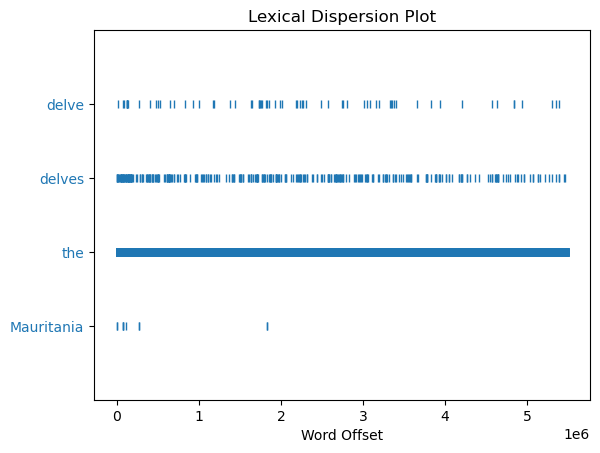

In [36]:
chatgpt_articles.dispersion_plot(["delve", "delves", "the", "Mauritania"])

## Creating Texts

In [37]:
from nltk.text import Text

In [38]:
Text(["Hello", "world", "!"])

<Text: Hello world !...>

## Generating Texts

The `.generate` function generates new text based on the statistical properties of an existing `Text`.

In [39]:
_ = Text(chatgpt_articles[:1000]).generate()

her a formidable adversary and romantic interest for Harvey . , one of
the show 's main characters . a popular American football player who
currently serves as a love interest for Harvey . that have shaped the
treatment of ethnic groups , including the Kurds , Baluchis , Arabs ,
and Turks , among others . Nevis participated in the international
sporting event . connector for commuters and locals traveling within
the region . . asset to the Packers defense . Although the city has no
snow and ice fields , it received quota spots in figure skating ,


Building ngram index...


## Next Time

Chapter 2